# 09. Phân loại với Truncated SVD từ đầu (SVD Classification from Scratch)

## 1. Cơ sở lý thuyết Chapter 20–21
Phân rã giá trị suy biến (Singular Value Decomposition):
$$X_c = U \Sigma V^T$$
Trong đó $V$ chứa các vector suy biến phải (right singular vectors), đại diện cho các trục biến thiên lớn nhất của dữ liệu. Bằng cách chọn $k$ cột đầu tiên của $V$, phép chiếu giảm chiều được thực hiện:
$$Z = X_c V_k^T$$
Không giống PCA yêu cầu tính toán ma trận hiệp phương sai $(d \times d)$, SVD áp dụng trực tiếp lên ma trận dữ liệu, giúp ổn định số học cao hơn.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.dimensionality_reduction.svd import TruncatedSVD
from src.models.logistic_regression import LogisticRegression
from src.models.knn_classifier import KNNClassifier
from src.metrics import calculate_metrics

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Khảo sát giá trị suy biến (Singular Values) và hiệu năng phân loại

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Asus\AppData\Local\Temp\ipykernel_10072\2388531435.py:6: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Singular Value $\sigma_i$')


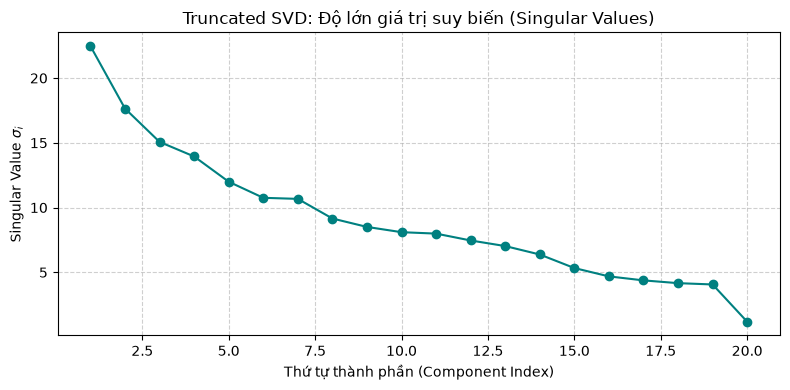

In [2]:
svd_full = TruncatedSVD(n_components=20).fit(X_train_proc)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(svd_full.singular_values_) + 1), svd_full.singular_values_, marker='o', color='teal')
plt.title('Truncated SVD: Độ lớn giá trị suy biến (Singular Values)')
plt.xlabel('Thứ tự thành phần (Component Index)')
plt.ylabel('Singular Value $\sigma_i$')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. So sánh hiệu năng mô hình theo số lượng thành phần SVD

In [3]:
comp_list = [2, 5, 10, 15, 20]
svd_results = []

for k in comp_list:
    svd = TruncatedSVD(n_components=k).fit(X_train_proc)
    X_tr_svd = svd.transform(X_train_proc)
    X_te_svd = svd.transform(X_test_proc)

    # Logistic Regression
    lr = LogisticRegression(learning_rate=0.05, epochs=1000, l2=0.01, random_state=42).fit(X_tr_svd, y_train)
    m_lr = calculate_metrics(y_test, lr.predict(X_te_svd), lr.predict_proba(X_te_svd)[:, 1])

    # KNN
    knn = KNNClassifier(n_neighbors=7, weights='distance').fit(X_tr_svd, y_train)
    m_knn = calculate_metrics(y_test, knn.predict(X_te_svd), knn.predict_proba(X_te_svd)[:, 1])

    svd_results.append({
        'Components': k,
        'LR_Accuracy': m_lr['Accuracy'],
        'LR_F1': m_lr['F1_Score'],
        'KNN_Accuracy': m_knn['Accuracy'],
        'KNN_F1': m_knn['F1_Score']
    })

df_svd = pd.DataFrame(svd_results)
display(df_svd)

,Components,LR_Accuracy,LR_F1,KNN_Accuracy,KNN_F1
0,2,0.847458,0.842105,0.779661,0.763636
1,5,0.830508,0.821429,0.796610,0.785714
2,10,0.830508,0.821429,0.813559,0.807018
3,15,0.864407,0.857143,0.881356,0.877193
4,20,0.830508,0.814815,0.847458,0.842105


## 4. Phân tích kết quả
- Với chỉ 5 đến 10 thành phần SVD (giảm hơn một nửa số chiều gốc), Logistic Regression và KNN đã đạt hiệu năng xấp xỉ dữ liệu gốc.
- Truncated SVD là phương pháp trích chọn đặc trưng mạnh mẽ, tương đương PCA nhưng có cấu trúc tính toán tối ưu hơn.